In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd drive/MyDrive/jax-f16-gcas-validation

/content/drive/MyDrive/jax-f16-gcas-validation


In [4]:
!pip install jaxlib
!pip install jax_f16

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.8 MB/s eta 0:00:00


In [5]:
!pip install --upgrade jax[cuda]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 18.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [6]:
import scipy as sp
from jax.scipy.stats.multivariate_normal import logpdf as multivar_gauss_logpdf


In [7]:
from simulate import *
from f16system import *
import matplotlib.pyplot as plt
import numpy as np

In [8]:
import gc

In [9]:
system = F16System(T=300)
nominal_mean = system.noise_mean
nominal_std = system.noise_std
# p = (nominal_mean, nominal_cov)

In [10]:
def generate_proposal_distributions(p_mean, p_std, num_proposals=1, mean_scale=1, std_scale=1):
    """
    generate proposal distributions by taking the nominal distribution
    parameters and perturbing them by a random value
    """
    qs = [] # proposal distributions
    mask = np.zeros(16) # which components we are going to change for proposal
    mask[3] = 1
    mask[6] = 1
    # create proposal distributions by slightly perturbing the parameters of nominal dist
    for i in range(num_proposals):
        # use mask to only change the noisy features
        q_mean = p_mean + (mean_scale * np.random.uniform(-1, 1, 16) * mask)
        q_std = p_std + (std_scale * np.random.uniform(0, 1, 16) * mask)
        # qs.append(jsp.stats.multivariate_normal(q_mean, system.noise_std))
        qs.append((q_mean, q_std))
    return qs

In [11]:
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.6508633e-05,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-03,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.0508633e-05,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-03,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
# proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -1.0508633e-06,
#         0.0000000e+00,  0.0000000e+00,  2.1600521e-04,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
#         0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 1.e-02, 1.e-10, 1.e-10, 3.e-02, 1.e-10,
#        1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.2e-03, 1.e-10, 1.e-10, 5.2e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]

In [ ]:
print(proposal)

[(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.0e-10, 1.0e-10, 1.0e-10, 5.2e-03, 1.0e-10, 1.0e-10, 5.2e-03,
       1.0e-10, 1.0e-10, 1.0e-10, 1.0e-10, 1.0e-10, 1.0e-10, 1.0e-10,
       1.0e-10, 1.0e-10]))]


In [ ]:
qs = generate_proposal_distributions(proposal[0][0], proposal[0][1], num_proposals=5, mean_scale=0, std_scale=1e-3)
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=70, mean_scale=5e-2, std_scale=1e-4)
# qs = generate_proposal_distributions(nominal_mean, nominal_std, num_proposals=50, mean_scale=1e-3, std_scale=0)
# x = [q[1][3] for q in qs]
# y = [q[1][6] for q in qs]
# plt.scatter(x, y)

In [ ]:
print(qs)
qs_plus = qs + proposal

[(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 5.98355033e-03,
       1.00000000e-10, 1.00000000e-10, 5.35274660e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10])), (array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 6.19699061e-03,
       1.00000000e-10, 1.00000000e-10, 5.85179607e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10])), (array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 5.33818259e-03,
       1.00000000e-10, 1.00000000e-10, 5.92544535e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.0000

In [11]:
def imp_sampl_fail_est(p, qs, num_rollouts, DMMIS=False):
    q_systems = []
    for q in qs:
        q_system = F16System(T=300, prop_noise_mean=q[0], prop_noise_std=q[1])
        q_systems.append(q_system)
    rollouts = []
    ws = []
    weighted_sum = 0
    rollout_cnt = 0
    estimates = []
    for j in tqdm(range(num_rollouts), desc="Running Rollouts"):
        for q in q_systems:
            rollout_cnt += 1
            rollout = q.rollout_min_altitude_and_loglik()
            gc.collect()
            rollouts.append(rollout)
            traj = rollout[2][2].reshape(-1, 16)
            p_i = gaussian_log_pdf_traj(traj, p.noise_mean, p.noise_cov)
            q_i = gaussian_log_pdf_traj(traj, q.sensor.mean, q.sensor.cov)
            # ws.append(np.exp(p_i - q_i))
            w_i = np.exp(p_i - q_i)
            if rollout[0] < CRASH_ALT:
                print("\nFound failure!")
                print(p_i)
                print(q_i)
                print("Weight is", w_i.item())
                weighted_sum += w_i.item()
            est = weighted_sum / rollout_cnt
            print("\nWeighted sum:", weighted_sum)
            print("\nFailure probability estimate after %d rollouts: %f" % (rollout_cnt, est))
            estimates.append(est)
        jax.clear_caches()
    return estimates

In [ ]:
estimates = imp_sampl_fail_est(system, qs, num_rollouts=50)
# estimates = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/50 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 3 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 4 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 5 rollouts: 0.000000


Running Rollouts:   2%|▏         | 1/50 [01:19<1:04:44, 79.27s/it]


Weighted sum: 0

Failure probability estimate after 6 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 7 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 8 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 9 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 10 rollouts: 0.000000


Running Rollouts:   4%|▍         | 2/50 [02:25<57:10, 71.46s/it]  

...


Weighted sum: 1.4537826746076457

Failure probability estimate after 201 rollouts: 0.007233

Weighted sum: 1.4537826746076457

Failure probability estimate after 202 rollouts: 0.007197

Weighted sum: 1.4537826746076457

Failure probability estimate after 203 rollouts: 0.007161

Weighted sum: 1.4537826746076457

Failure probability estimate after 204 rollouts: 0.007126

Weighted sum: 1.4537826746076457

Failure probability estimate after 205 rollouts: 0.007092


Running Rollouts:  82%|████████▏ | 41/50 [46:00<10:03, 67.09s/it]


Weighted sum: 1.4537826746076457

Failure probability estimate after 206 rollouts: 0.007057

Weighted sum: 1.4537826746076457

Failure probability estimate after 207 rollouts: 0.007023

Weighted sum: 1.4537826746076457

Failure probability estimate after 208 rollouts: 0.006989

Weighted sum: 1.4537826746076457

Failure probability estimate after 209 rollouts: 0.006956

Weighted sum: 1.4537826746076457

Failure probability estimate after 210 rollouts: 0.006923


Running Rollouts:  84%|████████▍ | 42/50 [47:09<09:02, 67.81s/it]


Weighted sum: 1.4537826746076457

Failure probability estimate after 211 rollouts: 0.006890

Weighted sum: 1.4537826746076457

Failure probability estimate after 212 rollouts: 0.006857

Weighted sum: 1.4537826746076457

Failure probability estimate after 213 rollouts: 0.006825

Weighted sum: 1.4537826746076457

Failure probability estimate after 214 rollouts: 0.006793


In [ ]:
# estimates = imp_sampl_fail_est(system, proposal, num_rollouts=100)

In [ ]:
# prob = [estimates[i] / (i+1) for i in range(len(estimates))]    # accidentally

Text(0, 0.5, 'Probability estimate')

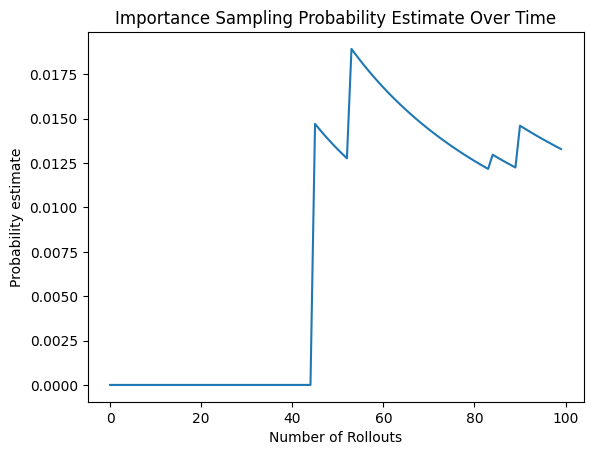

In [ ]:
plt.plot(np.arange(len(estimates)), estimates)
plt.title("Importance Sampling Probability Estimate Over Time")
plt.xlabel("Number of Rollouts")
plt.ylabel("Probability estimate")

In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.2e-03, 1.e-10, 1.e-10, 5.2e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
estimates = imp_sampl_fail_est(system, proposal, num_rollouts=100)


Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:15<25:32, 15.48s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:30<24:32, 15.03s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [25:34<00:32, 16.14s/it]


Weighted sum: 2.8786394596099854

Failure probability estimate after 99 rollouts: 0.029077


Running Rollouts:  99%|█████████▉| 99/100 [25:50<00:16, 16.10s/it]


Weighted sum: 2.8786394596099854

Failure probability estimate after 100 rollouts: 0.028786


Running Rollouts: 100%|██████████| 100/100 [26:06<00:00, 15.66s/it]


In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.1e-03, 1.e-10, 1.e-10, 5.1e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
estimates51 = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:15<25:25, 15.41s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:30<25:05, 15.36s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [25:21<00:32, 16.18s/it]


Weighted sum: 4.245431303977966

Failure probability estimate after 99 rollouts: 0.042883


Running Rollouts:  99%|█████████▉| 99/100 [25:36<00:16, 16.06s/it]


Weighted sum: 4.245431303977966

Failure probability estimate after 100 rollouts: 0.042454


Running Rollouts: 100%|██████████| 100/100 [25:52<00:00, 15.53s/it]


In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5.4e-03, 1.e-10, 1.e-10, 5.4e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
estimates54 = imp_sampl_fail_est(system, proposal, num_rollouts=100)

Running Rollouts:   0%|          | 0/100 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000


Running Rollouts:   1%|          | 1/100 [00:14<24:40, 14.95s/it]


Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000


Running Rollouts:   2%|▏         | 2/100 [00:30<24:46, 15.17s/it]

...

Running Rollouts:  98%|█████████▊| 98/100 [25:25<00:32, 16.05s/it]


Weighted sum: 0.15727658849209547

Failure probability estimate after 99 rollouts: 0.001589


Running Rollouts:  99%|█████████▉| 99/100 [25:41<00:16, 16.06s/it]


Weighted sum: 0.15727658849209547

Failure probability estimate after 100 rollouts: 0.001573


Running Rollouts: 100%|██████████| 100/100 [25:58<00:00, 15.58s/it]


In [18]:
def generate_proposal_distributions(p_mean, p_std, num_proposals=1, mean_scale=1, std_scale=1):
    """
    generate proposal distributions by taking the nominal distribution
    parameters and perturbing them by a random value
    """
    qs = [] # proposal distributions
    mask = np.zeros(16) # which components we are going to change for proposal
    mask[3] = 1
    mask[6] = 1
    # create proposal distributions by slightly perturbing the parameters of nominal dist
    for i in range(num_proposals):
        # use mask to only change the noisy features
        q_mean = p_mean + (mean_scale * np.random.randn(1) * mask)
        q_std = p_std + (std_scale * np.random.randn(1) * mask)
        # qs.append(jsp.stats.multivariate_normal(q_mean, system.noise_std))
        qs.append((q_mean, q_std))
    return qs

In [20]:
def imp_sampl_fail_est_new(p, qs, num_rollouts, DMMIS=False):
    q_systems = []
    for q in qs:
        q_system = F16System(T=300, prop_noise_mean=q[0], prop_noise_std=q[1], sensor_seed=5)
        q_systems.append(q_system)
    rollouts = []
    ws = []
    weighted_sum = 0
    rollout_cnt = 0
    estimates = []
    for j in tqdm(range(num_rollouts), desc="Running Rollouts"):
        for q in q_systems:
            rollout_cnt += 1
            rollout = q.rollout_min_altitude_and_loglik()
            gc.collect()
            rollouts.append(rollout)
            traj = rollout[2][2].reshape(-1, 16)
            p_i = gaussian_log_pdf_traj(traj, p.noise_mean, p.noise_cov)
            q_i = gaussian_log_pdf_traj(traj, q.sensor.mean, q.sensor.cov)
            # ws.append(np.exp(p_i - q_i))
            w_i = np.exp(p_i - q_i)
            if rollout[0] < CRASH_ALT:
                print("\nFound failure!")
                print(p_i)
                print(q_i)
                print("Weight is", w_i.item())
                weighted_sum += w_i.item()
            est = weighted_sum / rollout_cnt
            print("\nWeighted sum:", weighted_sum)
            print("\nFailure probability estimate after %d rollouts: %f" % (rollout_cnt, est))
            estimates.append(est)
        jax.clear_caches()
    return estimates

In [21]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5e-03, 1.e-10, 1.e-10, 5e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
qs = generate_proposal_distributions(proposal[0][0], proposal[0][1], num_proposals=10, mean_scale=0, std_scale=1e-3)
estimates = imp_sampl_fail_est_new(system, qs, num_rollouts=10)

Running Rollouts:   0%|          | 0/10 [00:00<?, ?it/s]


Found failure!
92916.27
92935.69
Weight is 3.70322239540144e-09

Weighted sum: 3.70322239540144e-09

Failure probability estimate after 1 rollouts: 0.000000

Weighted sum: 3.70322239540144e-09

Failure probability estimate after 2 rollouts: 0.000000

Weighted sum: 3.70322239540144e-09

Failure probability estimate after 3 rollouts: 0.000000

Weighted sum: 3.70322239540144e-09

Failure probability estimate after 4 rollouts: 0.000000

Weighted sum: 3.70322239540144e-09

Failure probability estimate after 5 rollouts: 0.000000

Weighted sum: 3.70322239540144e-09

Failure probability estimate after 6 rollouts: 0.000000

Found failure!
92981.25
92985.81
Weight is 0.010435936041176319

Weighted sum: 0.010435939744398715

Failure probability estimate after 7 rollouts: 0.001491

Weighted sum: 0.010435939744398715

Failure probability estimate after 8 rollouts: 0.001304

Weighted sum: 0.010435939744398715

Failure probability estimate after 9 rollouts: 0.001160

Weighted sum: 0.0104359397443987

Running Rollouts:  10%|█         | 1/10 [02:22<21:23, 142.64s/it]


Weighted sum: 0.010435939744398715

Failure probability estimate after 11 rollouts: 0.000949

Weighted sum: 0.010435939744398715

Failure probability estimate after 12 rollouts: 0.000870

Weighted sum: 0.010435939744398715

Failure probability estimate after 13 rollouts: 0.000803

Weighted sum: 0.010435939744398715

Failure probability estimate after 14 rollouts: 0.000745

Weighted sum: 0.010435939744398715

Failure probability estimate after 15 rollouts: 0.000696

Weighted sum: 0.010435939744398715

Failure probability estimate after 16 rollouts: 0.000652

Weighted sum: 0.010435939744398715

Failure probability estimate after 17 rollouts: 0.000614

Weighted sum: 0.010435939744398715

Failure probability estimate after 18 rollouts: 0.000580

Weighted sum: 0.010435939744398715

Failure probability estimate after 19 rollouts: 0.000549

Weighted sum: 0.010435939744398715

Failure probability estimate after 20 rollouts: 0.000522


Running Rollouts:  20%|██        | 2/10 [04:47<19:12, 144.07s/it]

...

Running Rollouts:  80%|████████  | 8/10 [19:22<04:50, 145.27s/it]


Weighted sum: 0.010435939744398715

Failure probability estimate after 81 rollouts: 0.000129

Weighted sum: 0.010435939744398715

Failure probability estimate after 82 rollouts: 0.000127

Weighted sum: 0.010435939744398715

Failure probability estimate after 83 rollouts: 0.000126

Weighted sum: 0.010435939744398715

Failure probability estimate after 84 rollouts: 0.000124

Weighted sum: 0.010435939744398715

Failure probability estimate after 85 rollouts: 0.000123

Weighted sum: 0.010435939744398715

Failure probability estimate after 86 rollouts: 0.000121

Weighted sum: 0.010435939744398715

Failure probability estimate after 87 rollouts: 0.000120

Weighted sum: 0.010435939744398715

Failure probability estimate after 88 rollouts: 0.000119

Weighted sum: 0.010435939744398715

Failure probability estimate after 89 rollouts: 0.000117

Weighted sum: 0.010435939744398715

Failure probability estimate after 90 rollouts: 0.000116


Running Rollouts:  90%|█████████ | 9/10 [21:49<02:25, 145.62s/it]


Weighted sum: 0.010435939744398715

Failure probability estimate after 91 rollouts: 0.000115

Weighted sum: 0.010435939744398715

Failure probability estimate after 92 rollouts: 0.000113

Weighted sum: 0.010435939744398715

Failure probability estimate after 93 rollouts: 0.000112

Weighted sum: 0.010435939744398715

Failure probability estimate after 94 rollouts: 0.000111

Weighted sum: 0.010435939744398715

Failure probability estimate after 95 rollouts: 0.000110

Weighted sum: 0.010435939744398715

Failure probability estimate after 96 rollouts: 0.000109

Weighted sum: 0.010435939744398715

Failure probability estimate after 97 rollouts: 0.000108

Weighted sum: 0.010435939744398715

Failure probability estimate after 98 rollouts: 0.000106

Weighted sum: 0.010435939744398715

Failure probability estimate after 99 rollouts: 0.000105

Weighted sum: 0.010435939744398715

Failure probability estimate after 100 rollouts: 0.000104


Running Rollouts: 100%|██████████| 10/10 [24:17<00:00, 145.78s/it]


In [23]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5e-03, 1.e-10, 1.e-10, 5e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
qs = generate_proposal_distributions(proposal[0][0], proposal[0][1], num_proposals=10, mean_scale=0, std_scale=2e-4)
estimates2 = imp_sampl_fail_est_new(system, qs, num_rollouts=10)

Running Rollouts:   0%|          | 0/10 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 3 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 4 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 5 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 6 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 7 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 8 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 9 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 10 rollouts: 0.000000


Running Rollouts:  10%|█         | 1/10 [02:27<22:08, 147.63s/it]


Weighted sum: 0

Failure probability estimate after 11 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 12 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 13 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 14 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 15 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 16 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 17 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 18 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 19 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 20 rollouts: 0.000000


Running Rollouts:  20%|██        | 2/10 [04:50<19:19, 144.94s/it]

...

Running Rollouts:  80%|████████  | 8/10 [19:30<04:53, 146.97s/it]


Weighted sum: 0

Failure probability estimate after 81 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 82 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 83 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 84 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 85 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 86 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 87 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 88 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 89 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 90 rollouts: 0.000000


Running Rollouts:  90%|█████████ | 9/10 [21:55<02:26, 146.25s/it]


Weighted sum: 0

Failure probability estimate after 91 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 92 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 93 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 94 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 95 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 96 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 97 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 98 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 99 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 100 rollouts: 0.000000


Running Rollouts: 100%|██████████| 10/10 [24:22<00:00, 146.30s/it]


In [ ]:
proposal = [(np.array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, 0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]), np.array([1.e-10, 1.e-10, 1.e-10, 5e-03, 1.e-10, 1.e-10, 5e-03, 1.e-10,
       1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10, 1.e-10]))]
qs = generate_proposal_distributions(proposal[0][0], proposal[0][1], num_proposals=10, mean_scale=2.6e-3, std_scale=0)
estimates2 = imp_sampl_fail_est_new(system, qs, num_rollouts=10)

Running Rollouts:   0%|          | 0/10 [00:00<?, ?it/s]


Weighted sum: 0

Failure probability estimate after 1 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 2 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 3 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 4 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 5 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 6 rollouts: 0.000000

Weighted sum: 0

Failure probability estimate after 7 rollouts: 0.000000

Found failure!
92801.53
93055.91
Weight is 0.0

Weighted sum: 0.0

Failure probability estimate after 8 rollouts: 0.000000


In [16]:
print(qs)

[(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 5.02293684e-03,
       1.00000000e-10, 1.00000000e-10, 5.11460607e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10])), (array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 4.88644224e-03,
       1.00000000e-10, 1.00000000e-10, 5.09448789e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.00000000e-10])), (array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 4.79832631e-03,
       1.00000000e-10, 1.00000000e-10, 5.03267079e-03, 1.00000000e-10,
       1.00000000e-10, 1.00000000e-10, 1.00000000e-10, 1.0000